In [142]:
import librosa
import numpy as np
import pretty_midi
import soundfile as sf
from scipy import stats
import noisereduce as nr
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, lfilter

In [143]:
song_acc = "FLLS"
input_cleaned_filename = f"mp3_input/bass_{song_acc}_clean.mp3"
output_std_filename = f"transcribed_output/bass_{song_acc}_std_transcribed.mid"

audio, sr = librosa.load(input_cleaned_filename)

In [144]:
seconds_start = 0
seconds_end = 10

audio = audio[seconds_start * sr :seconds_end*sr]

In [145]:
hop_length = 512 # default

In [146]:
### Extract Notes

f0 = librosa.yin(y=audio, fmin=40, fmax=400, sr=sr)
times = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=hop_length)

In [147]:
# Convert frequencies → MIDI notes
def hz_to_midi(hz):
    if hz <= 0 or np.isnan(hz):
        return None
    return int(round(69 + 12 * np.log2(hz / 440.0)))

midi_notes = [hz_to_midi(freq) for freq in f0]

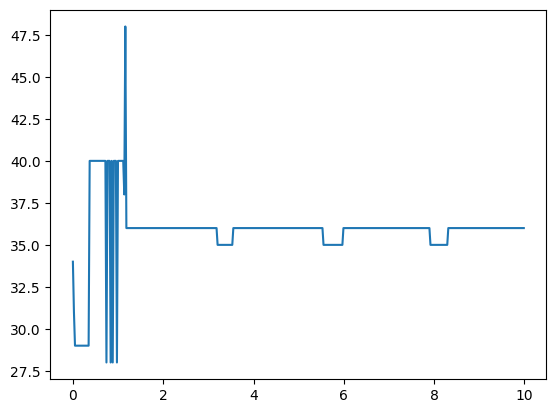

In [148]:
# frames = 500


plt.plot(times, midi_notes)
# beautify the x-labels

### Strums

In [149]:
X = librosa.stft(audio)
Xdb = librosa.amplitude_to_db(abs(X))

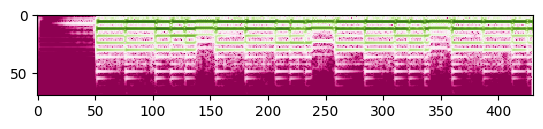

In [150]:
Xdb_condensed = Xdb[:70]

plt.imshow(Xdb_condensed, cmap='PiYG', interpolation='nearest')
plt.show()

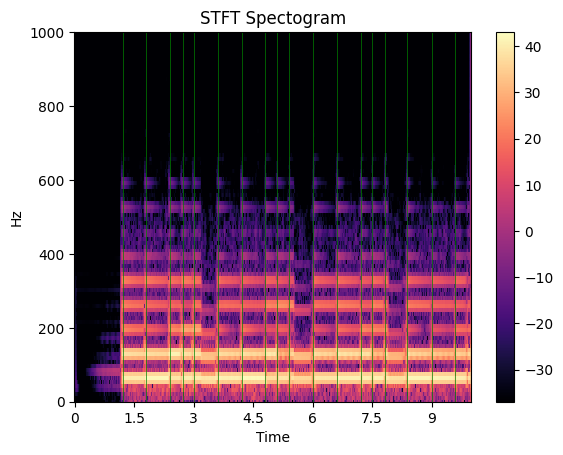

In [151]:
peak_prominence = 0.1

#column sums
col_sums = Xdb_condensed.sum(axis=0)
#standardize so that the same prominance can be used between songs 
col_sums_std = (col_sums - col_sums.min()) / (col_sums.max() - col_sums.min())
peaks_all, _ = find_peaks(col_sums_std, prominence=peak_prominence)

#turn indexes into times 
strums = librosa.frames_to_time(peaks_all, sr=sr, hop_length=512)


# plt.plot(col_sums_std)
# plt.plot(peaks_all, col_sums_std[peaks_all], "x", color = 'r')

librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.ylim(0, 1000)
plt.title('STFT Spectogram')
plt.colorbar()

for s in strums:
    plt.axvline(x=s, color='g', linewidth=0.5, linestyle="-")

### Strums against Notes

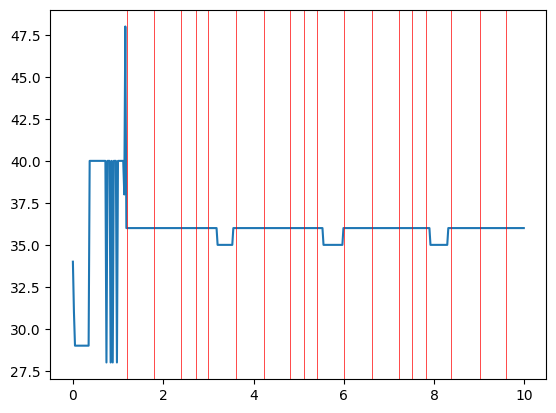

In [152]:
plt.plot(times, midi_notes)

for s in strums:
    plt.axvline(x=s, color='r', linewidth=0.5, linestyle="-")

In [153]:
### Split by peak indexes
midi_notes_strums = np.split(midi_notes, peaks_all)
midi_notes_strums

[array([34, 31, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 40,
        40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 28, 40,
        40, 40, 28, 40, 28, 40, 40, 40, 28, 40, 40, 40, 40, 40, 40, 38, 48,
        36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36,
        36, 36, 36, 36, 36, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36,
        36, 36, 36, 36, 36, 36, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 35, 35, 35, 35, 35, 35,
        35, 35, 35, 35, 35, 35, 35, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36,
        36, 36, 36, 36, 36, 36, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36,
        36, 36, 36, 36, 36, 36, 36, 36]),
 array([36, 36, 36, 36, 36, 

In [154]:
### Make all notes in a strum equal to the mode
# print(midi_notes_strums[1])

def mode_array(strum_notes):
    mode = stats.mode(strum_notes).mode
    mode_arr = np.full(len(strum_notes), int(mode)) # make array of mode same size as original
    return(mode_arr)

#remove_strum
def remove_strum(strum_notes):
    mode_arr = np.full(len(strum_notes), None)
    return(mode_arr)

def std_strum_notes(strums_all, remove_indexes):
    all_notes = np.array([])
    for i, strum_notes in enumerate(strums_all):
        remove = i in remove_indexes

        if remove:
            mode_arr = remove_strum(strum_notes)
        else:
            mode_arr = mode_array(strum_notes)
        
        all_notes = np.concat([all_notes, mode_arr])
    return(all_notes)

In [155]:
midi_notes_std = std_strum_notes(midi_notes_strums, [0])

### Turn to Midi

In [156]:
# build midi from sequence of midi notes 
# Build MIDI file
midi = pretty_midi.PrettyMIDI()
bass_program = pretty_midi.instrument_name_to_program("Acoustic Bass")
bass = pretty_midi.Instrument(program=bass_program)

# Group frames into sustained notes
current_note = None
note_start = None

for i, note in enumerate(midi_notes_std):
    if note is not None:
        if current_note is None:  # new note
            current_note = note
            note_start = times[i]
        elif note != current_note or i in peaks_all:  # pitch change → close old note, start new
            bass.notes.append(pretty_midi.Note(
                velocity=100, pitch=current_note,
                start=note_start, end=times[i]
            ))
            current_note = note
            note_start = times[i]
    else:
        if current_note is not None:  # end current note
            bass.notes.append(pretty_midi.Note(
                velocity=100, pitch=current_note,
                start=note_start, end=times[i]
            ))
            current_note = None
            note_start = None

# If song ends with a note still playing
if current_note is not None:
    bass.notes.append(pretty_midi.Note(
        velocity=100, pitch=current_note,
        start=note_start, end=times[-1]
    ))

midi.instruments.append(bass)

In [157]:
### Save Midi (Standardised)
midi.write(output_std_filename)